# Step 2 — System Anomaly 偵測

**目標**：找出系統層面的異常（device timeout、DB lock、queue stuck）

**修改下方 PARAMS cell 的參數後，Run All Cells**

In [1]:
# ===== 共用參數 =====
exec(open('../config/params.py').read())

# ===== 本步驟參數（修改這裡）=====
IQR_MULTIPLIER = 3              # per-device IQR 倍數（越大越嚴格）
QUEUE_STUCK_PERCENTILE = 99.0    # queue stuck 閾值取 non-contention 的第幾 percentile
# ==============================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
REPORTS_DIR = Path('../reports')

df = pd.read_csv(DATA_PATH)
df['order_created_at'] = pd.to_datetime(df['order_created_at'], format=DATETIME_FORMAT)

usr_flags = pd.read_csv('../data/user_anomaly_flags.csv')
df = df.merge(usr_flags, on='order_id')

print(f"Total: {len(df):,}, User contention: {df['is_user_anomaly'].sum():,}")


Total: 30,000, User contention: 159


## Queue Stuck 閾值推導

In [3]:
non_contention = df[~df['is_user_anomaly']]
queue_threshold = non_contention['queue_duration_seconds'].quantile(QUEUE_STUCK_PERCENTILE / 100)
print(f"Queue stuck threshold (P{QUEUE_STUCK_PERCENTILE} of non-contention): {queue_threshold:.0f}s")
print(f"Queue max: {df['queue_duration_seconds'].max()}s")

queue_stuck_count = (non_contention['queue_duration_seconds'] > queue_threshold).sum()
print(f"Orders > threshold: {queue_stuck_count}")

if queue_threshold < 120 and df['queue_duration_seconds'].max() < 300:
    print(f"\nℹ️  Queue duration 很小 (max={df['queue_duration_seconds'].max()}s)，可能不存在 queue stuck 問題")


Queue stuck threshold (P99.0 of non-contention): 288s
Queue max: 3631s
Orders > threshold: 299


## Per-Device IQR: Device Timeout + DB Lock

In [4]:
# Per-device IQR thresholds (computed on non-contention orders)
device_thresholds = non_contention.groupby('device_id').agg(
    dev_q1=('device_duration_avg_seconds', lambda x: x.quantile(0.25)),
    dev_q3=('device_duration_avg_seconds', lambda x: x.quantile(0.75)),
    db_q1=('db_duration_avg_seconds', lambda x: x.quantile(0.25)),
    db_q3=('db_duration_avg_seconds', lambda x: x.quantile(0.75)),
).reset_index()

device_thresholds['upper_device'] = device_thresholds['dev_q3'] + IQR_MULTIPLIER * (device_thresholds['dev_q3'] - device_thresholds['dev_q1'])
device_thresholds['upper_db'] = device_thresholds['db_q3'] + IQR_MULTIPLIER * (device_thresholds['db_q3'] - device_thresholds['db_q1'])

# IQR=0 check
dev_iqr_zero = ((device_thresholds['dev_q3'] - device_thresholds['dev_q1']) == 0).sum()
db_iqr_zero = ((device_thresholds['db_q3'] - device_thresholds['db_q1']) == 0).sum()
total_devices = len(device_thresholds)
print(f"IQR=0 devices: device={dev_iqr_zero}/{total_devices}, db={db_iqr_zero}/{total_devices}")
if dev_iqr_zero > total_devices * 0.2:
    print(f"⚠️  Device IQR=0 比例偏高 ({100*dev_iqr_zero/total_devices:.0f}%)，考慮改用固定 percentile threshold")

# Merge and flag
df = df.merge(device_thresholds[['device_id', 'upper_device', 'upper_db']], on='device_id')

df['is_system_anomaly'] = (
    ~df['is_user_anomaly'] & (
        (df['queue_duration_seconds'] > queue_threshold) |
        (df['device_duration_avg_seconds'] > df['upper_device']) |
        (df['db_duration_avg_seconds'] > df['upper_db'])
    )
)

anomalies = df[df['is_system_anomaly']]
print(f"\nSystem anomalies: {len(anomalies):,} / {len(df):,} ({100*len(anomalies)/len(df):.1f}%)")


IQR=0 devices: device=0/200, db=0/200

System anomalies: 683 / 30,000 (2.3%)


## 異常分類

In [5]:
# Classify
def classify_anomaly(row):
    reasons = []
    if row['queue_duration_seconds'] > queue_threshold:
        reasons.append('queue_stuck')
    if row['device_duration_avg_seconds'] > row['upper_device']:
        reasons.append('device_timeout')
    if row['db_duration_avg_seconds'] > row['upper_db']:
        reasons.append('db_lock')
    return ', '.join(reasons) if reasons else 'unknown'

anomalies = anomalies.copy()
anomalies['anomaly_type'] = anomalies.apply(classify_anomaly, axis=1)

print("Anomaly type breakdown:")
type_counts = anomalies['anomaly_type'].str.split(', ').explode().value_counts()
for t, c in type_counts.items():
    print(f"  {t}: {c}")


Anomaly type breakdown:
  queue_stuck: 299
  device_timeout: 207
  db_lock: 177


## 圖表

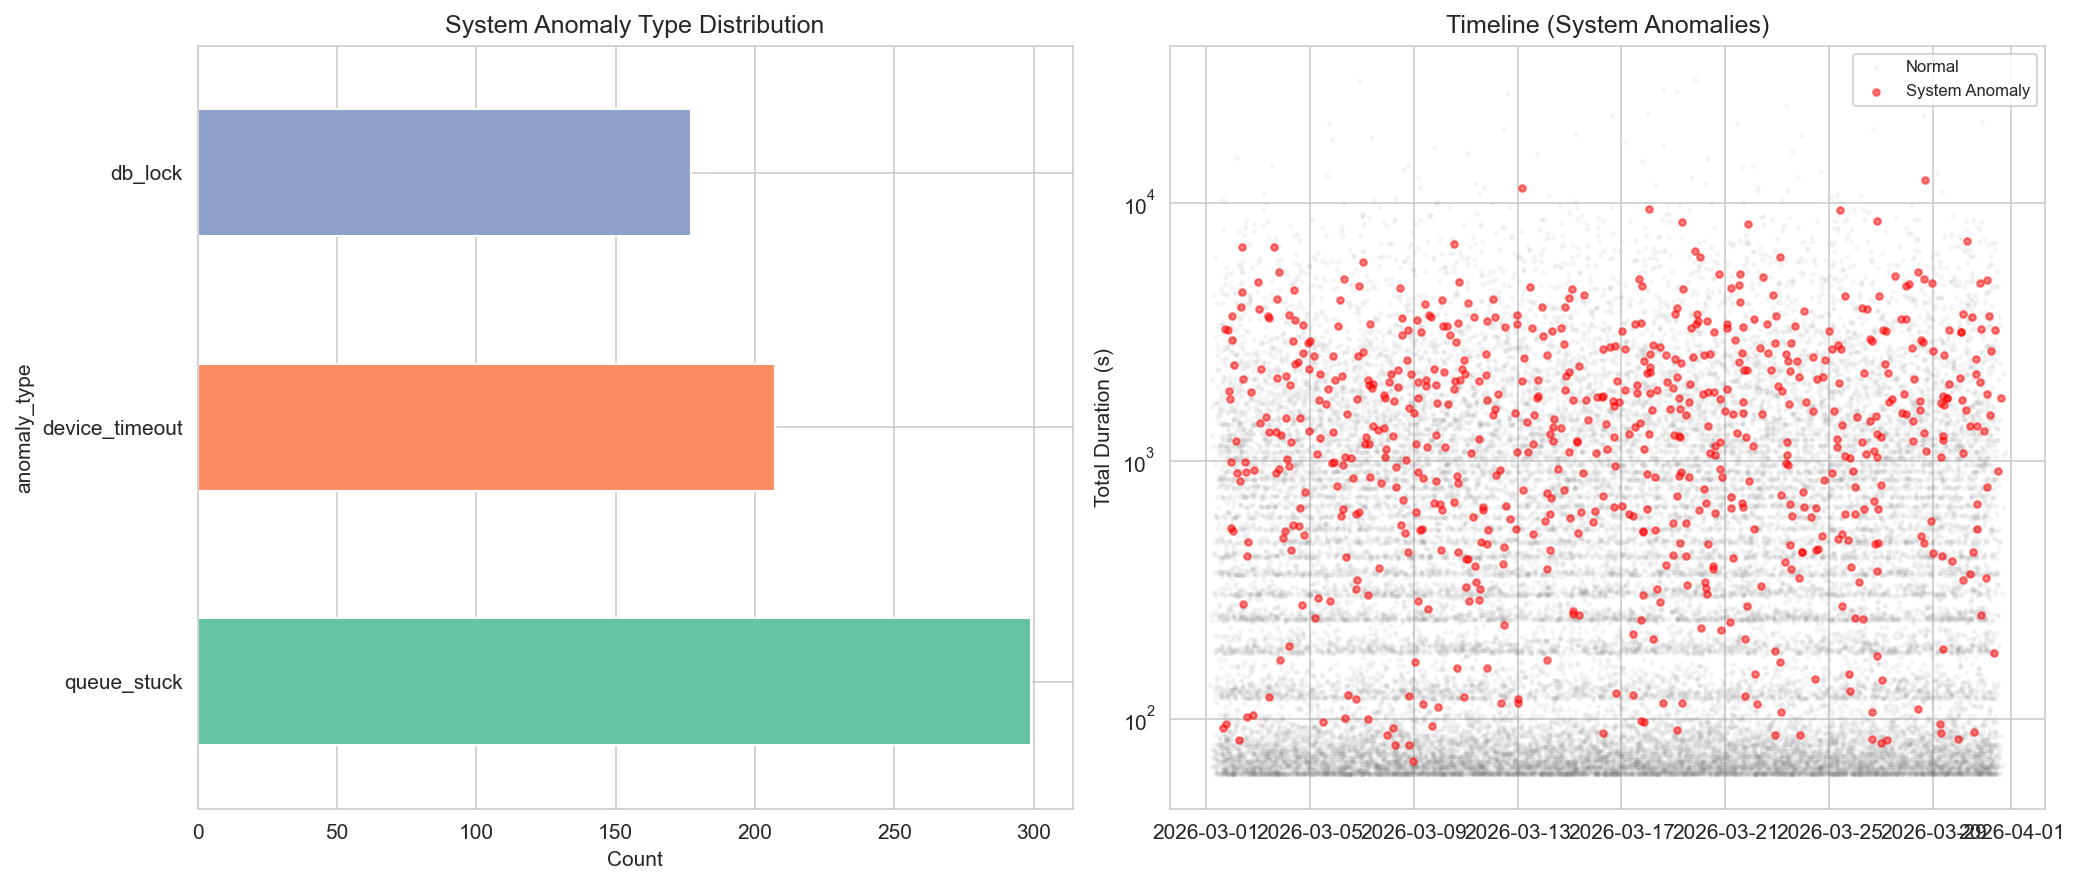

In [6]:
# Chart 1: Anomaly type + dominant phase
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

type_counts.plot(kind='barh', ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('System Anomaly Type Distribution')
axes[0].set_xlabel('Count')

# Timeline
ax = axes[1]
normal = df[~df['is_system_anomaly'] & ~df['is_user_anomaly']]
ax.scatter(normal['order_created_at'], normal['total_duration_seconds'],
           alpha=0.05, s=3, color='gray', label='Normal')
ax.scatter(anomalies['order_created_at'], anomalies['total_duration_seconds'],
           alpha=0.5, s=10, c='red', label='System Anomaly')
ax.set_title('Timeline (System Anomalies)')
ax.set_ylabel('Total Duration (s)')
ax.set_yscale('log')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step2_system_anomaly.png', dpi=150)
plt.show()


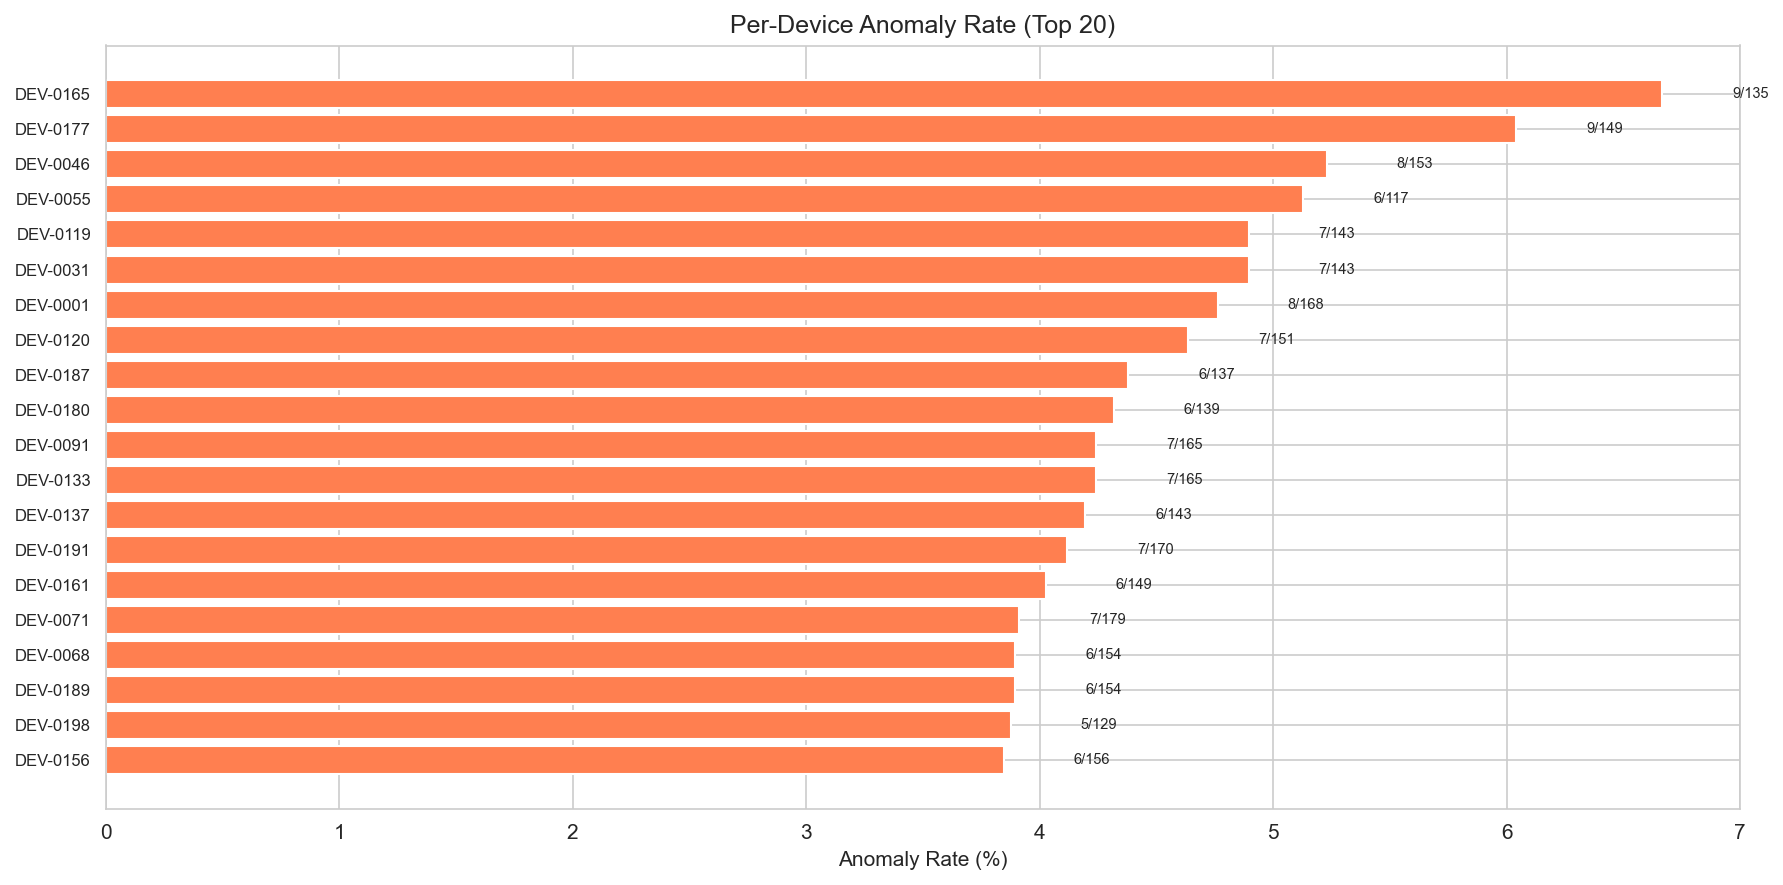

In [7]:
# Per-device anomaly rate (top 20)
dev_anomaly_rate = df.groupby('device_id')['is_system_anomaly'].agg(['mean', 'sum', 'count'])
dev_anomaly_rate = dev_anomaly_rate.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
top20 = dev_anomaly_rate.head(20)
ax.barh(range(len(top20)), top20['mean'] * 100, color='coral')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=8)
ax.set_title('Per-Device Anomaly Rate (Top 20)')
ax.set_xlabel('Anomaly Rate (%)')
ax.invert_yaxis()
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(row['mean']*100 + 0.3, i, f'{int(row["sum"])}/{int(row["count"])}', va='center', fontsize=7)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step2_device_anomaly_rate.png', dpi=150)
plt.show()


## 抽查驗證

以下隨機抽 20 筆異常 + 20 筆正常訂單。
請人工確認異常訂單是否合理（duration 明顯偏高），正常訂單是否有漏標。

In [8]:
# 抽查用：隨機抽 20 筆異常 + 20 筆正常，供人工驗證
print("=== 異常訂單抽查樣本（20 筆）===")
sample_cols = ['order_id', 'device_id', 'queue_duration_seconds',
               'device_duration_avg_seconds', 'db_duration_avg_seconds',
               'file_count', 'total_duration_seconds']
if len(anomalies) > 0:
    n_sample = min(20, len(anomalies))
    print(anomalies[sample_cols].sample(n=n_sample, random_state=42).to_string(index=False))
else:
    print("（無異常訂單）")

print("\n=== 正常訂單抽查樣本（20 筆）===")
normal_orders = df[~df['is_system_anomaly'] & ~df['is_user_anomaly']]
if len(normal_orders) > 0:
    n_sample = min(20, len(normal_orders))
    print(normal_orders[sample_cols].sample(n=n_sample, random_state=42).to_string(index=False))


=== 異常訂單抽查樣本（20 筆）===
  order_id device_id  queue_duration_seconds  device_duration_avg_seconds  db_duration_avg_seconds  file_count  total_duration_seconds
ORD-009505  DEV-0062                       3                          492                        2         303                    3161
ORD-003994  DEV-0162                    2127                            1                        2         812                    2907
ORD-004241  DEV-0121                    1907                            4                        2          22                    1967
ORD-010156  DEV-0109                     120                            9                        1          46                     111
ORD-022317  DEV-0137                    2207                            1                        1          16                    2267
ORD-023936  DEV-0056                       5                          356                        1         212                    1248
ORD-021987  DEV-0191             

## 匯出

In [9]:
anomaly_flags = df[['order_id', 'is_system_anomaly']].copy()
anomaly_flags.to_csv('../data/system_anomaly_flags.csv', index=False)
print(f"Exported: data/system_anomaly_flags.csv ({anomaly_flags['is_system_anomaly'].sum():,} anomalies)")

print(f"\n=== Step 2 Summary ===")
print(f"Params: IQR_MULTIPLIER={IQR_MULTIPLIER}, QUEUE_STUCK_PERCENTILE=P{QUEUE_STUCK_PERCENTILE}")
print(f"Queue stuck threshold: {queue_threshold:.0f}s")
print(f"System anomalies: {len(anomalies):,} ({100*len(anomalies)/len(df):.1f}%)")
for t, c in type_counts.items():
    print(f"  {t}: {c}")
print(f"IQR=0 devices: device={dev_iqr_zero}, db={db_iqr_zero}")


Exported: data/system_anomaly_flags.csv (683 anomalies)

=== Step 2 Summary ===
Params: IQR_MULTIPLIER=3, QUEUE_STUCK_PERCENTILE=P99.0
Queue stuck threshold: 288s
System anomalies: 683 (2.3%)
  queue_stuck: 299
  device_timeout: 207
  db_lock: 177
IQR=0 devices: device=0, db=0
